In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Markdown, display, Image

ROOT = Path.cwd()
if not (ROOT / 'artifacts').exists():
    ROOT = Path('c:/PathSense_Complete/PathSense_Complete/PDS/pathsense/ml')

DATASET_PATH = ROOT.parent / 'dataset' / 'pedestrian_accidents.csv'
REPORT_DIR = ROOT / 'artifacts' / 'report_assets'
TABLES_DIR = REPORT_DIR / 'tables'
VISUALS_DIR = REPORT_DIR / 'visuals'

print('ML root:', ROOT)
print('Dataset path:', DATASET_PATH)
print('Report assets path:', REPORT_DIR)

ML root: c:\PathSense_Complete\PathSense_Complete\PDS\pathsense\ml
Dataset path: c:\PathSense_Complete\PathSense_Complete\PDS\pathsense\dataset\pedestrian_accidents.csv
Report assets path: c:\PathSense_Complete\PathSense_Complete\PDS\pathsense\ml\artifacts\report_assets


In [4]:
data = pd.read_csv(DATASET_PATH)
print('Dataset shape:', data.shape)
data.head(5)

Dataset shape: (3000, 11)


,Pedestrian_Involved,Accident Severity,Time of Day,Day of Week,Weather Conditions,Lighting Conditions,Road Type,Road Condition,Traffic Control Presence,Speed Limit (km/h),Number of Vehicles Involved
0,0,Serious,1:46,Monday,Hazy,Dark,National Highway,Wet,Signs,61,5
1,0,Minor,21:30,Wednesday,Hazy,Dusk,Urban Road,Dry,Signs,92,5
2,1,Minor,5:37,Wednesday,Foggy,Dawn,National Highway,Under Construction,Signs,120,5
3,0,Minor,0:31,Saturday,Rainy,Dark,State Highway,Dry,Signals,76,3
4,0,Minor,11:21,Thursday,Foggy,Dusk,Urban Road,Wet,Signs,115,5


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Pedestrian_Involved          3000 non-null   int64 
 1   Accident Severity            3000 non-null   object
 2   Time of Day                  3000 non-null   object
 3   Day of Week                  3000 non-null   object
 4   Weather Conditions           3000 non-null   object
 5   Lighting Conditions          3000 non-null   object
 6   Road Type                    3000 non-null   object
 7   Road Condition               3000 non-null   object
 8   Traffic Control Presence     3000 non-null   object
 9   Speed Limit (km/h)           3000 non-null   int64 
 10  Number of Vehicles Involved  3000 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 257.9+ KB


In [7]:
data.isna().sum()

Pedestrian_Involved            0
Accident Severity              0
Time of Day                    0
Day of Week                    0
Weather Conditions             0
Lighting Conditions            0
Road Type                      0
Road Condition                 0
Traffic Control Presence       0
Speed Limit (km/h)             0
Number of Vehicles Involved    0
dtype: int64

In [9]:
working_data = data.copy()
working_data.columns = working_data.columns.str.strip()
working_data = working_data.dropna()

def categorize_time(time_str):
    hour = int(str(time_str).split(':')[0])
    if 5 <= hour < 12:
        return 'Morning'
    if 12 <= hour < 17:
        return 'Afternoon'
    if 17 <= hour < 21:
        return 'Evening'
    return 'Night'

working_data['Time_Category'] = working_data['Time of Day'].apply(categorize_time)
working_data['High_Risk'] = working_data['Accident Severity'].apply(lambda x: 1 if x in ['Serious', 'Fatal'] else 0)
working_data['High_Risk_Label'] = working_data['High_Risk'].map({0: 'Low Risk', 1: 'High Risk'})

working_data[['Accident Severity', 'Time of Day', 'Time_Category', 'High_Risk_Label']].head()

,Accident Severity,Time of Day,Time_Category,High_Risk_Label
0,Serious,1:46,Night,High Risk
1,Minor,21:30,Night,Low Risk
2,Minor,5:37,Morning,Low Risk
3,Minor,0:31,Night,Low Risk
4,Minor,11:21,Morning,Low Risk


In [10]:
display(Markdown((TABLES_DIR / 'preprocessing_steps.md').read_text(encoding='utf-8')))

# Data Preprocessing Steps

        1. Loaded the pedestrian accident dataset from the project dataset folder.
        2. Removed rows with missing values using `dropna()`.
        3. Trimmed column names to prevent whitespace mismatches.
        4. Converted `Time of Day` into a categorical feature called `Time_Category`.
        5. Built the binary target `High_Risk`, where Serious and Fatal cases are mapped to 1.
        6. Dropped non-model columns: `Accident Severity`, `High_Risk`, `Pedestrian_Involved`, and the raw `Time of Day`.
        7. Label-encoded all categorical predictors to make them model-ready.
        8. Split the encoded data into stratified training and testing sets with an 80/20 ratio.
        9. Trained Logistic Regression, Decision Tree, Random Forest, and XGBoost on the same split for comparison.


In [11]:
dataset_description = pd.read_csv(TABLES_DIR / 'dataset_description.csv')
dataset_description

,Metric,Value
0,Dataset Source,pathsense/dataset/pedestrian_accidents.csv
1,Rows,3000
2,Columns,11
3,Categorical Features,7
4,Numeric Features,2
5,Target Variable,"High_Risk (Serious/Fatal = 1, Minor = 0)"


In [12]:
initial_results = pd.read_csv(TABLES_DIR / 'initial_result_table.csv')
initial_results

,Metric,Value
0,Training Rows,2400
1,Testing Rows,600
2,Low Risk Samples,1034
3,High Risk Samples,1966
4,Missing Values Removed,0
5,Engineered Feature,Time_Category derived from Time of Day


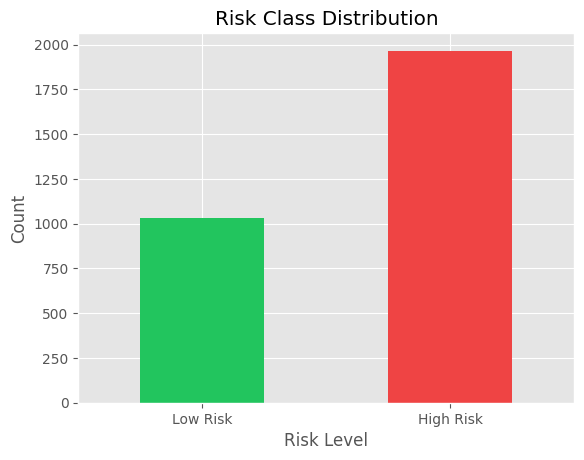

In [20]:
plt.style.use('ggplot')
risk_counts = working_data['High_Risk_Label'].value_counts().reindex(['Low Risk', 'High Risk'])
risk_counts.plot(kind='bar', color=['#22c55e', '#ef4444'], title='Risk Class Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


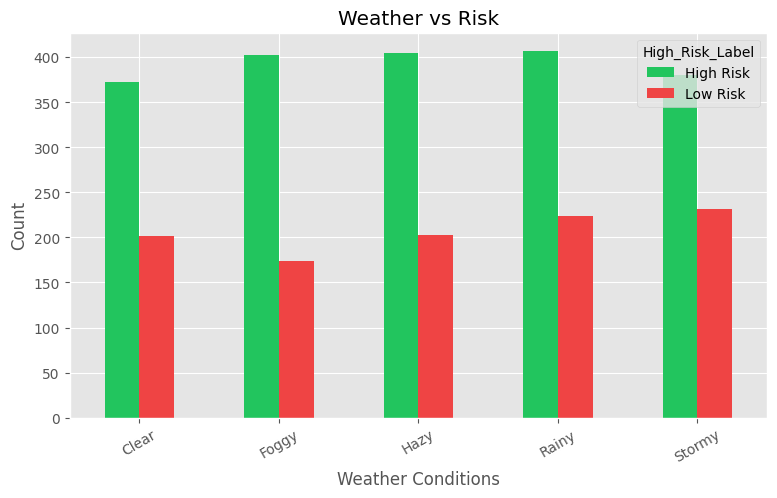

In [21]:
weather_risk = working_data.groupby(['Weather Conditions', 'High_Risk_Label']).size().unstack(fill_value=0)
weather_risk.plot(kind='bar', color=['#22c55e', '#ef4444'], title='Weather vs Risk', figsize=(9, 5))
plt.xlabel('Weather Conditions')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()


In [ ]:
road_risk = working_data.groupby(['Road Type', 'High_Risk_Label']).size().unstack(fill_value=0)
road_risk.plot(kind='bar', color=['#22c55e', '#ef4444'], title='Road Type vs Risk', figsize=(9, 5))
plt.xlabel('Road Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()


In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(working_data[working_data['High_Risk_Label'] == 'Low Risk']['Speed Limit (km/h)'], bins=20, alpha=0.7, color='#22c55e', label='Low Risk')
plt.hist(working_data[working_data['High_Risk_Label'] == 'High Risk']['Speed Limit (km/h)'], bins=20, alpha=0.7, color='#ef4444', label='High Risk')
plt.title('Speed Limit Distribution by Risk')
plt.xlabel('Speed Limit (km/h)')
plt.ylabel('Count')
plt.legend()
plt.show()


In [ ]:
time_risk = working_data.groupby(['Time_Category', 'High_Risk_Label']).size().unstack(fill_value=0)
time_risk.plot(kind='bar', color=['#22c55e', '#ef4444'], title='Time Category vs Risk', figsize=(9, 5))
plt.xlabel('Time Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


In [ ]:
day_risk = working_data.groupby(['Day of Week', 'High_Risk_Label']).size().unstack(fill_value=0)
day_risk.plot(kind='bar', color=['#22c55e', '#ef4444'], title='Day of Week vs Risk', figsize=(10, 5))
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()


In [ ]:
traffic_risk = working_data.groupby(['Traffic Control Presence', 'High_Risk_Label']).size().unstack(fill_value=0)
traffic_risk.plot(kind='bar', color=['#22c55e', '#ef4444'], title='Traffic Control vs Risk', figsize=(9, 5))
plt.xlabel('Traffic Control Presence')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()


In [ ]:
avg_speed = working_data.groupby('High_Risk_Label')['Speed Limit (km/h)'].mean().reindex(['Low Risk', 'High Risk'])
avg_speed.plot(kind='bar', color=['#22c55e', '#ef4444'], title='Average Speed Limit by Risk', figsize=(8, 5))
plt.xlabel('Risk Level')
plt.ylabel('Average Speed Limit (km/h)')
plt.xticks(rotation=0)
plt.show()


In [18]:
performance_table = pd.read_csv(TABLES_DIR / 'model_performance_table.csv')
performance_table

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6550,0.6550,1.0000,0.7915,0.5417
1,Random Forest,0.6433,0.6613,0.9338,0.7743,0.5178
2,Decision Tree,0.5833,0.6731,0.7074,0.6898,0.5373
3,XGBoost,0.5183,0.6520,0.5674,0.6068,0.5117


In [14]:
comparative_table = pd.read_csv(TABLES_DIR / 'comparative_table.csv')
comparative_table

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Accuracy Gap From Best
0,Logistic Regression,0.6550,0.6550,1.0000,0.7915,0.5417,0.0000
1,Random Forest,0.6433,0.6613,0.9338,0.7743,0.5178,0.0117
2,Decision Tree,0.5833,0.6731,0.7074,0.6898,0.5373,0.0717
3,XGBoost,0.5183,0.6520,0.5674,0.6068,0.5117,0.1367


In [17]:
display(Markdown((TABLES_DIR / 'key_observations.md').read_text(encoding='utf-8')))

# Key Observations From Visuals

    1. The dataset contains 1966 high-risk rows and 1034 low-risk rows, showing that the target is moderately imbalanced toward high-risk outcomes.
    2. The weather categories with the highest high-risk share are: Foggy (69.79%), Hazy (66.61%), Clear (64.81%).
    3. The road types with the highest high-risk share are: State Highway (67.32%), National Highway (66.89%).
    4. High-risk scenarios have a higher average speed limit (75.26 km/h) than low-risk scenarios (74.33 km/h).
    5. Lighting conditions, road condition, and number of vehicles appear as the strongest XGBoost features, indicating that environment and traffic density matter more than road type alone.
    6. The best holdout-accuracy model in the current comparison is Logistic Regression with accuracy 0.6550 and ROC-AUC 0.5417.


In [19]:
best_model = performance_table.sort_values('Accuracy', ascending=False).iloc[0]
print('Best Model:', best_model['Model'])
print('Accuracy:', best_model['Accuracy'])
print('ROC-AUC:', best_model['ROC-AUC'])

Best Model: Logistic Regression
Accuracy: 0.655
ROC-AUC: 0.5417
